### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - \$50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [280]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [281]:
data = pd.read_csv('data/coupons.csv')

In [282]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [283]:
#Check for duplicates 
print(data.duplicated().sum())
#Keep only unique ocurrences
print("Before:", data.shape)
data = data.drop_duplicates()
print("After:", data.shape)
#Check for missing data
data.isnull().sum()

74
Before: (12684, 26)
After: (12610, 26)


destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12502
Bar                       107
CoffeeHouse               217
CarryAway                 150
RestaurantLessThan20      129
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [284]:
#Check for issues with data types
data.dtypes
data['age'].unique()
data['time'].unique()
#Ordering the categories for age and time
age_order = ['below 21', '21', '26', '31', '36', '41', '46', '50plus']
time_order =['7AM', '10AM', '2PM','6PM', '10PM']

3. Decide what to do about your missing data -- drop, replace, other...

In [285]:
#Dropping column "car" since it has only a few non-null values
data = data.drop(columns=['car'])   
print(data.shape)
#Dropping rows with missing values for columns: Bar, CoffeeHouse, CarryAway, 
#RestaurantLessThan20 and Restaurant20To50
data = data.dropna(subset=['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50'])
print(data.shape)

(12610, 25)
(12007, 25)


4. What proportion of the total observations chose to accept the coupon?



In [286]:
#Calculation the proportion of the ones who accepted the coupon
prop_accepted = data['Y'].mean()
print(f"Proportion accepted: {prop_accepted:.4f}")

Proportion accepted: 0.5684


5. Use a bar plot to visualize the `coupon` column.

Text(0.5, 1.0, 'Distribution of Coupon Types')

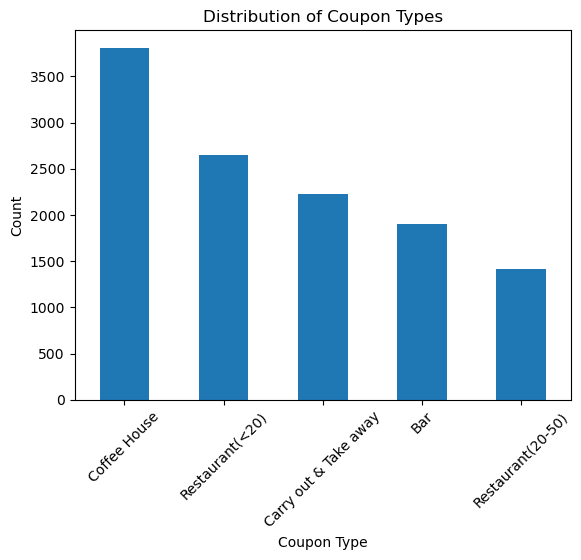

In [287]:
#Create a bar plot of coupons count by category in matplotlib
data['coupon'].value_counts().plot(kind='bar')
plt.xticks(rotation=45)
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.title('Distribution of Coupon Types')

6. Use a histogram to visualize the temperature column.

Text(0.5, 1.0, 'Histogram of Temperature')

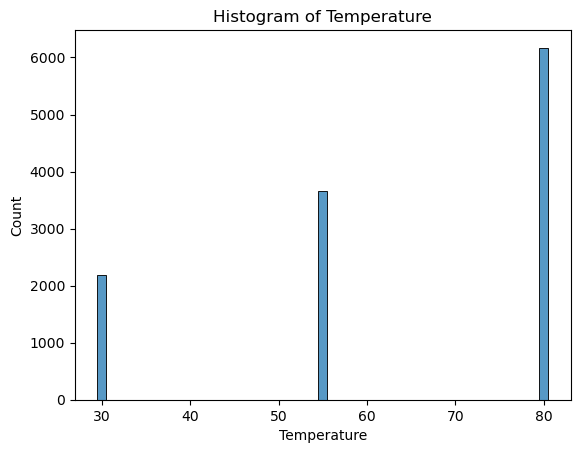

In [288]:
#Create a histogram for temperature with seaborn
sns.histplot(data=data, x='temperature', discrete=True)
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.title('Histogram of Temperature')

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [289]:
#Create a new DataFrame that contains just the bar coupons
bar_coupons = data.query('coupon == "Bar"')

2. What proportion of bar coupons were accepted?


In [290]:
#Calculate the proportion of bar coupons accepted
prop_bar_coupons_acc = bar_coupons['Y'].mean()
print(f"Proportion Bar Coupons accepted: {prop_bar_coupons_acc:.4f}")
print(prop_bar_coupons_acc)

Proportion Bar Coupons accepted: 0.4119
0.4118572927597062


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [291]:
#Check all the categories for Bar
bar_coupons['Bar'].unique()

#Calculate the acceptance rate for the two groups by frequency of visiting bars
high_freq = bar_coupons[bar_coupons['Bar'].isin(['4~8', 'gt8'])]['Y'].mean()
low_freq = bar_coupons[~bar_coupons['Bar'].isin(['4~8', 'gt8'])]['Y'].mean()
print(f"Acceptance rate, 4+ times/month: {high_freq:.4f}")
print(f"Acceptance rate , less than 4 times/month: {low_freq:.4f}")
print(f"Acceptance rate for bar coupons for low frequency bar visitors is: {low_freq / high_freq:.4f} fraction from the high frequency bar visitors")


Acceptance rate, 4+ times/month: 0.7617
Acceptance rate , less than 4 times/month: 0.3724
Acceptance rate for bar coupons for low frequency bar visitors is: 0.4890 fraction from the high frequency bar visitors


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [292]:
#Calculate the acceptance rate of drivers who go to a bar more than once a month and are over the age of 25
#Check all values for age
bar_coupons['age'].unique()
#Select the group of people who meet both conditions
more_than_once = bar_coupons[bar_coupons['Bar'].isin(['1~3', 'gt8', '4~8'])]
over25 = more_than_once[more_than_once['age'].isin(['26', '31','36','41', '46', '50plus'])]
#Calculate the acceptance rate of the group older than 25 that visit bars more than once a month
print(f"Acceeptance rate , more than once a month and over 25:  {over25['Y'].mean():.4f}")

#Select the group: "all others"
all_others = bar_coupons.drop(over25.index)
print(f"Acceptance rate, all others:  {all_others['Y'].mean():.4f}")

print("Yes, there is a difference. Acceptance rate for the first group over 25 and going to bars more than once per month is more than double the acceptance rate from all others")


Acceeptance rate , more than once a month and over 25:  0.6898
Acceptance rate, all others:  0.3373
Yes, there is a difference. Acceptance rate for the first group over 25 and going to bars more than once per month is more than double the acceptance rate from all others


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [293]:
#Checking categories for passanger and occupation
bar_coupons['passanger'].unique()
bar_coupons['occupation'].unique()
#Select the group of people who meet all conditions
more_than_once_pass_occ = bar_coupons.query( 
    'Bar in ["1-3", "4-8", "gt8"] and passanger != "Kid(s)" and occupation not in ["Farming Fishing & Forestry"]'
)
#Calculate the acceptance rate
more_than_once_pass_occ['Y'].mean()
print(f"Acceeptance rate , more than once a month, no kid as a passenger and not from Farming Fishing & Forestry occupation:  {more_than_once_pass_occ['Y'].mean():.4f}")
#Select all others
all_others_pass_occ = bar_coupons.drop(more_than_once_pass_occ.index)
#Calculate acceptance rate from all others
all_others_pass_occ['Y'].mean()
print(f"Acceptance rate, all others:  {all_others_pass_occ['Y'].mean():.4f}")
print("Yes, there is a difference. Acceptance rate for the first group is roughtly 1.75 times higher acceptance rate than the rest.")

Acceeptance rate , more than once a month, no kid as a passenger and not from Farming Fishing & Forestry occupation:  0.7111
Acceptance rate, all others:  0.4046
Yes, there is a difference. Acceptance rate for the first group is roughtly 1.75 times higher acceptance rate than the rest.


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [294]:
#Select groups for each condition as listed

condition_1 = (bar_coupons['Bar'].isin(['1~3','4~8','gt8'])) & (bar_coupons['passanger'] != 'Kid(s)') & (bar_coupons['maritalStatus'] != 'Widowed')
condition_1

condition_2 = (bar_coupons['Bar'].isin(['1~3','4~8','gt8'])) & (bar_coupons['age'].isin(['below21', '21', '26']))
condition_2

condition_3 = (bar_coupons['RestaurantLessThan20'].isin(['4~8','gt8'])) & (bar_coupons['income'].isin(['$12500 - $24999', '$37500 - $49999', '$25000 - $37499', 'Less than $12500']))
condition_3

#Select the rows that meet any of the conditions
meet_any_condition = condition_1 | condition_2 | condition_3

#Gather all the rows that meet any of the three conditions to get the target group
target_group = bar_coupons[meet_any_condition]
#Calculate the acceptance rate from the target group
target_group['Y'].mean()
#Get the all_others group
all_others = bar_coupons.drop(target_group.index)
#Calculate the acceptance rate from the all_others group
all_others['Y'].mean()


print(f"Acceeptance rate from target group, which meets any condition {target_group['Y'].mean():.4f}")
print(f"Acceptance rate, all others:  {all_others['Y'].mean():.4f}")

print("The acceptance rate from the target group, which meets at least one of the three conditions, is significantly higher than the one from the all others group")

Acceeptance rate from target group, which meets any condition 0.5871
Acceptance rate, all others:  0.2991
The acceptance rate from the target group, which meets at least one of the three conditions, is significantly higher than the one from the all others group


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In general, roughly 41% of coupons are accepted. However, people who go to bars more frequently, are more much likely to accept the coupon.
Age is also a factor that enhance the probability of accepting a coupon along with the fact that the person goes to a bar at least once a month. 
People over 25 that go to bars at least once a month have a significantly higher acceptance rate than average.
Two other significant factors are the passenger and occupation. If they were NOT accompanied by a kid and had a different occupation than fishing, farming and forestry, their acceptance rate was much higher than the rest of the people.
A particular combination of factors that describe a budget conscious person also proved to have an effect on the acceptance rate. People who frequent cheap restaurants, and had lower incomes accepted these coupon more.
Overall, this suggests bar coupons perform best among drivers who are already bar-goers with flexible schedules and budget conscious spending habits, rather than occasional or infrequent visitors.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

Will answer questions on acceptance rates for Coffee House coupons

In [295]:
data['coupon'].unique()
#Create a dataframe that contains just the Coffee House coupons
coffee_house_coupons = data.query('coupon == "Coffee House"').copy()




In [296]:
#Calculate the proportion of coupons that were accepted
prop_coffee_coupons_accepted = coffee_house_coupons['Y'].mean()
print(f"Proportion Coffee House Coupons accepted: {prop_coffee_coupons_accepted:.4f}")


Proportion Coffee House Coupons accepted: 0.4957


In [297]:
#Order values for income, age and time
income_order = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999',
                '$50000 - $62499', '$62500 - $74999', '$75000 - $87499', '$87500 - $99999', '$100000 or More']
coffee_house_coupons['income']=pd.Categorical(coffee_house_coupons['income'], categories=income_order, ordered=True)
time_order = ['7AM', '10AM', '2PM', '6PM', '10PM']
coffee_house_coupons['time']=pd.Categorical(coffee_house_coupons['time'], categories=time_order, ordered=True)
age_order = ['below21', '21', '26', '31', '36', '41','46','50plus']
coffee_house_coupons['age']=pd.Categorical(coffee_house_coupons['age'], categories=age_order, ordered=True)

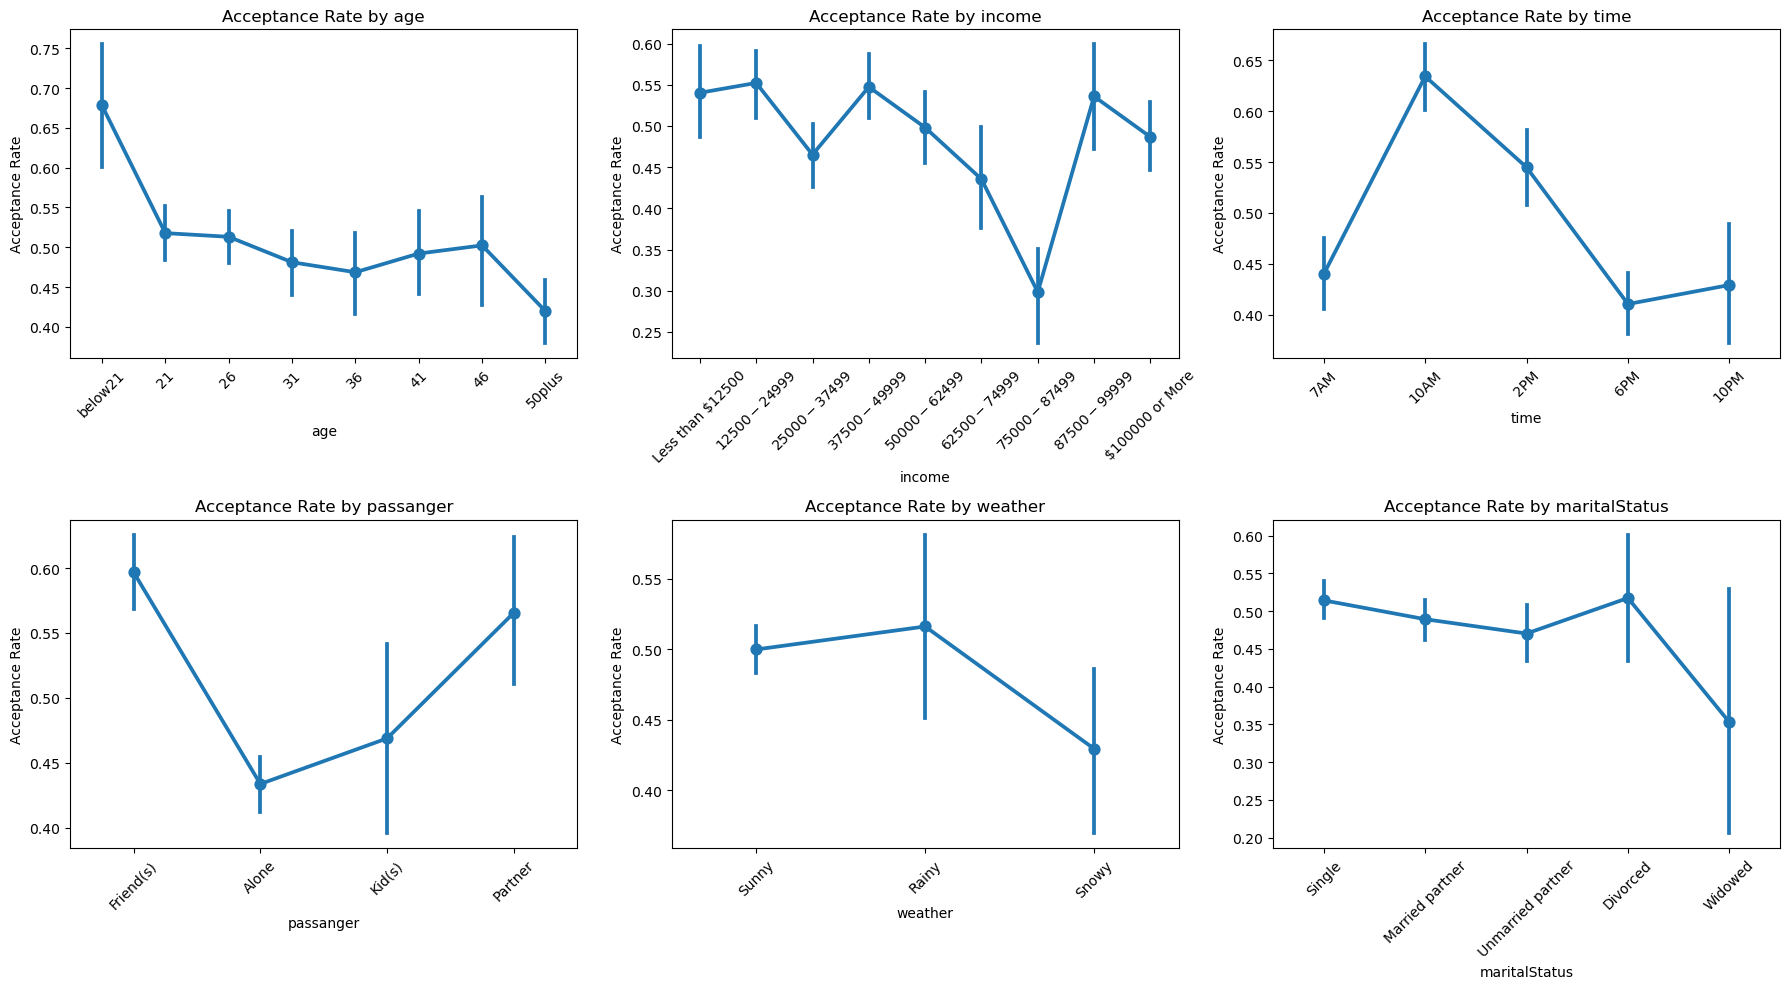

In [298]:
#Create a grid of subplots for coffee house coupons with six factors: Age, Income, Time, Passanger, Weather and Marital Status

variables = ['age', 'income','time','passanger','weather','maritalStatus']
fig, axes = plt.subplots(nrows=2,ncols=3, figsize=(18,10))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.pointplot(data=coffee_house_coupons, x=var, y='Y', ax=axes[i])
    axes[i].set_title(f'Acceptance Rate by {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Acceptance Rate')
    axes[i].tick_params(axis='x', rotation=45)
    plt.tight_layout()

Compare acceptance rate between those drivers who:
are below 21 years old and are driving with a friend OR
have an income of less than 25K OR
are driving at 10AM in a sunny day

In [299]:
#Calculate the acceptance rate for a group of people who meet at least one of three conditions described above
condition_1 = (coffee_house_coupons['age'].isin(['below21'])) & (coffee_house_coupons['passanger'] == 'Friend(s)')
condition_2 =  coffee_house_coupons['income'].isin(['Less than $12500', '$12500 - $24999'])
condition_3 = (coffee_house_coupons['time'] == '10AM') & (coffee_house_coupons['weather'] == 'Sunny')
meet_any_condition = condition_1 | condition_2 | condition_3
target_group = coffee_house_coupons[meet_any_condition]
all_others = coffee_house_coupons.drop(target_group.index)

print(f"Acceptance rate, target group: {target_group['Y'].mean():.4f}")
print(f"Acceptance rate, all others: {all_others['Y'].mean():.4f}")

Acceptance rate, target group: 0.5848
Acceptance rate, all others: 0.4387


In [300]:

#Analyze if low income has a significant impact by calculating the acceptance rate for low income people
low_income = coffee_house_coupons[coffee_house_coupons['income'].isin(['Less than $12500', '$12500 - $24999'])]
print(f"Acceptance rate, income < $25K: {low_income['Y'].mean():.4f}")
print(f"Overall baseline:{prop_coffee_coupons_accepted:.4f}")

Acceptance rate, income < $25K: 0.5481
Overall baseline:0.4957


In [301]:
#Calculate the acceptance rate only including conditions 1 and three (removing low income)
condition_1_v2 = (coffee_house_coupons['age'].isin(['below21'])) & (coffee_house_coupons['passanger'] == 'Friend(s)')
condition_3_v2 = (coffee_house_coupons['time'] == '10AM') & (coffee_house_coupons['weather'] == 'Sunny')
meet_any_condition_v2 = condition_1_v2 | condition_3_v2
target_group = coffee_house_coupons[meet_any_condition_v2]
all_others = coffee_house_coupons.drop(target_group.index)

print(f"Acceptance rate, target group: {target_group['Y'].mean():.4f}")
print(f"Acceptance rate, all others: {all_others['Y'].mean():.4f}")

Acceptance rate, target group: 0.6416
Acceptance rate, all others: 0.4570


Conclusion

Overall, 49.57% of coffee house coupons were accepted. To test whether the individual patterns observed in the plots above actually predict
acceptance when combined, I first compared drivers meeting any of three conditions: under 21 with a friend passenger, income under 25K, or driving at 10AM in sunny weather against everyone else. This combined group accepted at 58.48%, versus 43.87% for all others, confirming that these factors do matter together, not just individually.
I then looked more closely at income on its own, since its effect in the plot was less consistent than the other factors. Drivers earning under 25K accepted at 54.81% only about five points above baseline. This proves to be a real but modest effect, clearly weaker than age, passenger,time, and weather were showing. Given that, I removed income from the combined group and ran the comparison again using just age + passenger + weather. This redefined group accepted coffee house coupons at 64.16% versus 45.70% for everyone else, a much larger, more reliable gap than the three factor version.
This suggests the strongest, more actionable driver of coffee house coupon acceptance is a combination of being a younger driver accompanied by a friend or partner, driving in the late morning, and in favorable weather. Income shows a smaller, secondary relationship worth noting but not one that meaningfully strengthens the prediction once the strongest factors are already accounted for.